In [92]:
import matplotlib.pyplot as plt
from os import environ
'''environ["OMP_NUM_THREADS"] = "1"
environ["OPENBLAS_NUM_THREADS"] = "1"
environ["MKL_NUM_THREADS"] = "1"
environ["VECLIB_MAXIMUM_THREADS"] = "1"
environ["NUMEXPR_NUM_THREADS"] = "1"'''
import numpy as np
import math
import multiprocessing
from multiprocessing import Pool
import csv
from numpy import linalg as la
#from scipy.stats import kde
#from scipy.fftpack import fft, ifft
#from IPython import get_ipython;   
#from itertools import repeat, izip
#get_ipython().magic('reset -sf')
#plt.close('all')

n = 4000

sigma = 2.0
a = -0.1
b = 0.1
d = 1.0

alpha = 0.5
kboundup = 2.0
kbounddown = 2.0

mu =0.0

eff0 = 0.001


tmax = 1000


numtrial = 1

numsample = 100


def phi(x):

    myphi = x*np.heaviside(x+kbounddown,0.0)*np.heaviside(kboundup-x,0.0) + kboundup*(1.0-np.heaviside(kboundup-x,0.0)) -kbounddown*(1.0-np.heaviside(x+kbounddown,0.0))    

    return myphi;

def phidashed(x):

    myphidashed = np.heaviside(x+kbounddown,0.0)*np.heaviside(kboundup-x,0.0) 

    return myphidashed;

if __name__ == '__main__':


    sampvec = np.zeros(numsample)
    
    
    axx = np.zeros((n,n))
                
    #construct random interaction matrix
    for i in range(0,n): 
        for k in range(0,i):
            rand2 = np.random.uniform(0.0,1.0, 1)[0]
            rand3 = np.random.uniform(0.0,1.0, 1)[0]
            if rand2<0.5:
                axx[i][k] = mu-sigma/np.sqrt(n)
            if rand2>0.5:
                axx[i][k] = mu+sigma/np.sqrt(n)
            if rand3<0.5:
                axx[k][i] = mu-sigma/np.sqrt(n)
            if rand3>0.5:
                axx[k][i] = mu+sigma/np.sqrt(n)
            '''axx[i][k] = np.random.normal(0.0, sigma/np.sqrt(n), 1)[0]
            axx[k][i] = np.random.normal(0.0, sigma/np.sqrt(n), 1)[0]'''


      
    x = np.random.uniform(-2.0,2.0, n)
    y = np.random.uniform(-2.0*b,2.0*b, n)
    step = 0
    t = 0
    #Numerical integration
    while t <= tmax:

        h = axx.dot(x)
        myx = np.copy(x)
        x = alpha*(d-a*x**2+y)+ (1.0-alpha)*phi(h)
        y = b*myx
        


        step = step +1
        t = t + 1

    flag = 0
    ind = 0
    while flag==0 and ind<n:
        if(h[ind]>eff0-kbounddown and h[ind]<kboundup-eff0):
            flag = 1
        ind = ind +1

    ind = ind-1
    step = 0
    while t <= tmax + numsample:

        h = axx.dot(x)
        myx = np.copy(x)
        x = alpha*(d-a*x**2+y)+ (1.0-alpha)*phi(h)
        y = b*myx

        sampvec[step] = np.copy(x[ind])
        step = step +1
        t = t + 1

        
    xstar = np.copy(x)
    hstar = np.copy(h)



    print("Run complete")
    
    '''nstar = np.copy(n)
    for k in range(0,n):
        if x[k] <eff0-kbound or x[k]>kbound-eff0:
            axx = np.delete(axx, k-(n-nstar), 0)
            axx = np.delete(axx, k-(n-nstar), 1)
            xstar = np.delete(xstar, k-(n-nstar), 0)
            hstar = np.delete(hstar, k-(n-nstar), 0)
            nstar = nstar - 1'''
	
    xdiag = np.diag(xstar)  
    id = np.identity(n)
        

    jac1 = np.zeros((2*n,2*n))
    #phidash = 4.0*g*kbound*np.exp(2.0*g*h)/(np.exp(2.0*g*h)+1.0)**2

    id = np.identity(n)
    h = axx.dot(x)

    for i in range(0,n):
        jac1[i][n+i] = alpha
        jac1[n+i][i] = b
        for j in range(0, n):
            jac1[i][j] = id[i][j]*(-2.0*a*x[i]*alpha) +phidashed(h[i])*axx[i][j]*(1.0-alpha)


    

    print("Jacobian constructed")
    evaluesj1, evectorsj1 = la.eig(jac1)
    print("Eigenvalues found")



    
    #np.savetxt("lambdaversusr_sig0point2_n8000.csv", lambdavec, delimiter=",")
    #np.savetxt("rvecsim_sig0point2_n8000.csv", rvec, delimiter=",")

    








Run complete
Jacobian constructed
Eigenvalues found


C:\Users\jwb96\AppData\Local\Temp\ipykernel_29532\2313150232.py:92: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
C:\Users\jwb96\AppData\Local\Temp\ipykernel_29532\2313150232.py:115: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
C:\Users\jwb96\AppData\Local\Temp\ipykernel_29532\2313150232.py:143: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
C:\Users\jwb96\AppData\Local\Temp\ipykernel_29532\2313150232.py:162: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


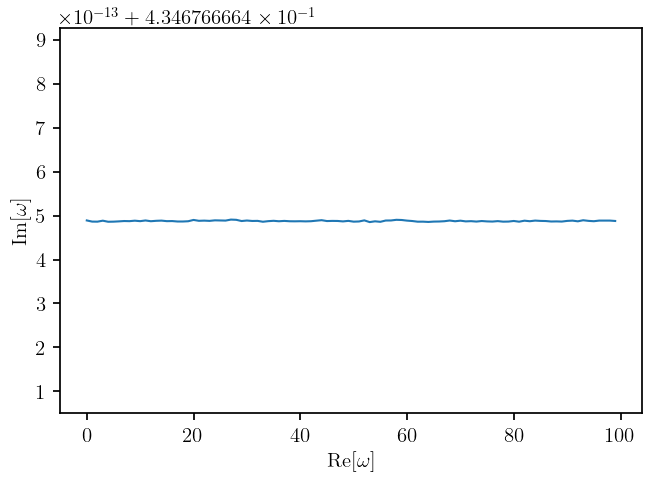

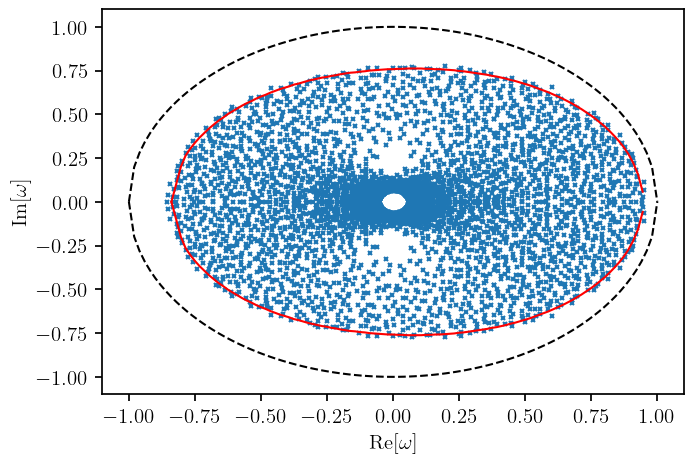

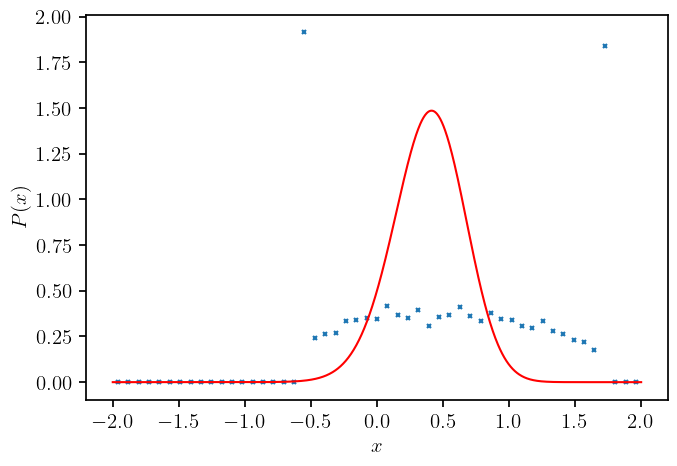

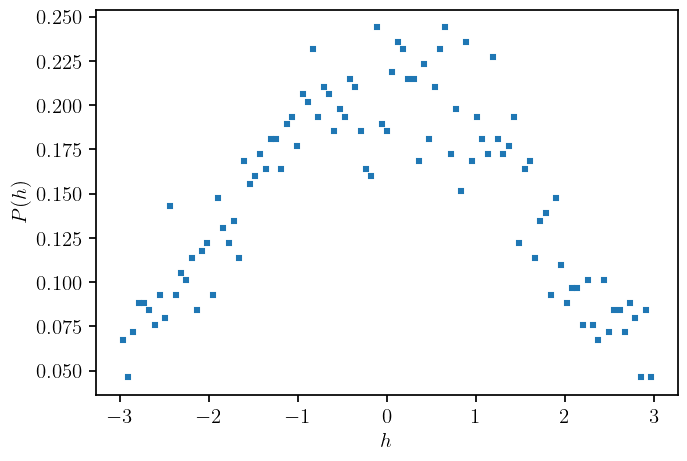

In [94]:
import matplotlib.pyplot as plt
import numpy as np
import math
import multiprocessing
from multiprocessing import Pool
import csv
from numpy import linalg as la
#from scipy.stats import kde
#from itertools import repeat, izip
#from IPython import get_ipython;
#get_ipython().magic('reset -sf')
#plt.close('all')






eff0 = 0.001
effinf = 10.0**5


if __name__ == '__main__':


	xmin = -2.0
	xmax = 2.0
	numbins = 51
	binedges = np.linspace(xmin, xmax, numbins+1, endpoint=True)
	bins = np.linspace(xmin+float((xmax-xmin)/(numbins-1))*0.5, xmax-float((xmax-xmin)/(numbins-1))*0.5, numbins, endpoint=True)		
	xhist = np.histogram(xstar, binedges)[0]


	hmin = -3.0
	hmax = 3.0
	numbinsh = 101
	binedgesh = np.linspace(hmin, hmax, numbinsh+1, endpoint=True)
	binsh = np.linspace(hmin+float((hmax-hmin)/(numbinsh-1))*0.5, hmax-float((hmax-hmin)/(numbinsh-1))*0.5, numbinsh, endpoint=True)		

	hhist = np.histogram(h, binedgesh)[0]


	
	#Plotting

	SIZE = 15

	plt.rc('font', size=SIZE)          # controls default text sizes
	plt.rc('axes', titlesize=SIZE)     # fontsize of the axes title
	plt.rc('axes', labelsize=SIZE)    # fontsize of the x and y labels
	plt.rc('xtick', labelsize=SIZE)    # fontsize of the tick labels
	plt.rc('ytick', labelsize=SIZE)    # fontsize of the tick labels
	plt.rc('legend', fontsize=SIZE-5)    # legend fontsize
	plt.rc('text', usetex=True)
	plt.rcParams['axes.linewidth'] = 1.25
	plt.rcParams['legend.loc'] = 'best'

	edgewidth = 1.5
	lwidth = 1.25
	size = 7.5
	tickwidth = 1.25
	ticklength = 5
	padness = 5
	fsize = 5





	xvec = np.genfromtxt('xvec.csv', dtype = float, delimiter=',', skip_footer=0)
	yvec = np.genfromtxt('critomvec.csv', dtype = float, delimiter=',', skip_footer=0)
	

	xvecth = np.genfromtxt('xvec_henon.csv', dtype = float, delimiter=',', skip_footer=0)
	histvecth = np.genfromtxt('pxvec_henon.csv', dtype = float, delimiter=',', skip_footer=0)


	fig1 = plt.figure(figsize=(7.5,5))
	ax1 = fig1.add_subplot(111)
	ax1.plot(np.linspace(0,numsample-1, numsample, endpoint = True), sampvec, '-', markersize = (size -4.5), markeredgewidth = edgewidth)
	axes = plt.gca()
	#axes.set_xlim([-1.0,1.0])
	#axes.set_ylim([-2.3, 2.3])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$\mathrm{Re}[\omega]$")
	ax1.set_ylabel(r"$\mathrm{Im}[\omega]$")
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()

	xth = np.linspace(-1.0, 1.0, 101, endpoint= True)
	#yth = np.sqrt((g**2*kbound**2- xth**2)*np.heaviside(g**2*kbound**2- xth**2,0.0))
	
	fig1 = plt.figure(figsize=(7.5,5))
	ax1 = fig1.add_subplot(111)
	ax1.plot(np.real(evaluesj1), np.imag(evaluesj1), 'x', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(xvec, abs(yvec), '-', color = 'r', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(xvec, -abs(yvec), '-', color = 'r', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(xth, np.sqrt(1.0-xth**2), '--', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(xth, -np.sqrt(1.0-xth**2), '--', color = 'k', markersize = (size -4.5), markeredgewidth = edgewidth)
	axes = plt.gca()
	#axes.set_xlim([-1.0,1.0])
	#axes.set_ylim([-0.5, 0.5])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$\mathrm{Re}[\omega]$")
	ax1.set_ylabel(r"$\mathrm{Im}[\omega]$")
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()

	

	plt.savefig("jacbian_henon.svg", format="svg")






	fig1 = plt.figure(figsize=(7.5,5))
	ax1 = fig1.add_subplot(111)
	ax1.plot(bins, xhist/float(n)*float(numbins)/(xmax-xmin), 'x', markersize = (size -4.5), markeredgewidth = edgewidth)
	ax1.plot(xvecth, histvecth, '-', markersize = (size -4.5), markeredgewidth = edgewidth, color = 'r')
	#ax1.plot(xvecth, np.exp(-(xvecth-(1-1/r))**2/(2.0*(sigma**2+sigma**4)*(1-1/r)**2))/np.sqrt(2.0*np.pi*(1-1/r)**2*(sigma**2+sigma**4)), '--', markersize = (size -4.5), markeredgewidth = edgewidth, color = 'r')
	axes = plt.gca()
	#axes.set_ylim([0.0, ])
	#axes.set_xlim([-0.2, 0.2])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$x$")
	ax1.set_ylabel(r"$P(x)$")
	#ax1.set_yscale('log')
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()

	

	fig1 = plt.figure(figsize=(7.5,5))
	ax1 = fig1.add_subplot(111)
	ax1.plot(binsh, hhist/float(n)*float(numbinsh)/(hmax-hmin), 's', markersize = (size -4.5), markeredgewidth = edgewidth)
	axes = plt.gca()
	#axes.set_ylim([0.0, 8])
	#axes.set_xlim([0.0, 1.0])
	#axes.set_ylim([0,max(hist[0]/float(numtrial))])
	ax1.set_xlabel(r"$h$")
	ax1.set_ylabel(r"$P(h)$")
	#ax1.set_yscale('log')
	#ax1.legend()
	ax1.tick_params(width = tickwidth, length = ticklength)
	ax1.tick_params(pad=padness)
	#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
       		#verticalalignment='top', bbox=props, color='black')
	fig1.show()


	#plt.savefig("pdx.svg", format="svg")
	

In [40]:
sum(x**2)/float(n)

np.float64(1.5891823211594525)

In [134]:
max(abs(evaluesj1))

np.float64(0.972758760447278)

In [21]:
print(sum(fakedx**2)/float(numfakehist))
print(sum((x2-x1)**2)/float(n))

print(sum(fakedx)/float(numfakehist))

5.688679869861877
1.030260407560692e-05
0.019969743281923674


In [32]:
print([q1, q2, q12, (q1+q2)/2.0])
print((q1+q2-2.0*q12)*0.5)
fakeq1 = sum(fakex1**2)/float(numfakehist)
fakeq2 = sum(fakex2**2)/float(numfakehist)
fakeq12 = sum(fakex2*fakex2)/float(numfakehist)
print([fakeq1, fakeq2, fakeq12, (fakeq1+fakeq2)/2.0])
print((fakeq1+fakeq2-2.0*fakeq12)*0.5)

[np.float64(0.33093484356743164), np.float64(0.3308355993925708), np.float64(0.3308800701779781), np.float64(0.3308852214800012)]
5.151302023109761e-06
[np.float64(0.33079958571838947), np.float64(0.3312540810408521), np.float64(0.3312540810408521), np.float64(0.3310268333796208)]
-0.00022724766123127793


In [4]:
print([q1, q2, q12, (q1+q2)/2.0])
print((q1+q2-2.0*q12)*0.5)
fakeq1 = sum(fakex1**2)/float(numfakehist)
fakeq2 = sum(fakex2**2)/float(numfakehist)
fakeq12 = sum(fakex2*fakex2)/float(numfakehist)
print([fakeq1, fakeq2, fakeq12, (fakeq1+fakeq2)/2.0])
print((fakeq1+fakeq2-2.0*fakeq12)*0.5)

[np.float64(0.38567286796690253), np.float64(0.38600178709329797), np.float64(0.3853378502970218), np.float64(0.38583732753010025)]
0.0004994772330784714
[np.float64(0.36748132122893573), np.float64(0.3653616599296895), np.float64(0.3653616599296895), np.float64(0.3664214905793126)]
0.001059830649623117


C:\Users\jwb96\AppData\Local\Temp\ipykernel_25920\62651262.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


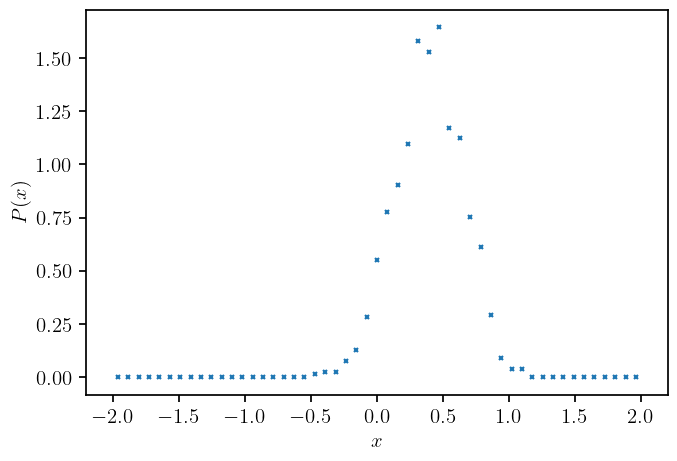

In [157]:
fig1 = plt.figure(figsize=(7.5,5))
ax1 = fig1.add_subplot(111)
ax1.plot(bins, xhist/float(n)*float(numbins)/(xmax-xmin), 'x', markersize = (size -4.5), markeredgewidth = edgewidth)
ax1.plot(xvecth, histvecth, '-', markersize = (size -4.5), markeredgewidth = edgewidth, color = 'r')
#ax1.plot(xvecth, np.exp(-(xvecth-(1-1/r))**2/(2.0*(sigma**2+sigma**4)*(1-1/r)**2))/np.sqrt(2.0*np.pi*(1-1/r)**2*(sigma**2+sigma**4)), '--', markersize = (size -4.5), markeredgewidth = edgewidth, color = 'r')
axes = plt.gca()
#axes.set_ylim([0.0, ])
#axes.set_xlim([-0.2, 0.2])
#axes.set_ylim([0,max(hist[0]/float(numtrial))])
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$P(x)$")
#ax1.set_yscale('log')
#ax1.legend()
ax1.tick_params(width = tickwidth, length = ticklength)
ax1.tick_params(pad=padness)
#ax1.text(0.8, 0.15, r"(a)", transform=ax1.transAxes, fontsize=fsize,
      		#verticalalignment='top', bbox=props, color='black')
fig1.show()

In [4]:
np.random.choice([-1,1],nstar)

array([ 1,  1, -1, ..., -1, -1, -1], shape=(3288,))

In [156]:
histvecth

array([5.63020887e-12, 9.82452460e-12, 1.72188707e-11, 3.03012508e-11,
       5.35220379e-11, 9.48573768e-11, 1.68625378e-10, 3.00560499e-10,
       5.36955903e-10, 9.61126495e-10, 1.72302671e-09, 3.09246078e-09,
       5.55450311e-09, 9.98021850e-09, 1.79312523e-08, 3.22014753e-08,
       5.77765065e-08, 1.03526105e-07, 1.85174528e-07, 3.30485217e-07,
       5.88255335e-07, 1.04381457e-06, 1.84553404e-06, 3.24979953e-06,
       5.69663585e-06, 9.93565026e-06, 1.72335864e-05, 2.97124974e-05,
       5.08939761e-05, 8.65633319e-05, 1.46121983e-04, 2.44670629e-04,
       4.06163145e-04, 6.68092081e-04, 1.08830606e-03, 1.75470250e-03,
       2.79865606e-03, 4.41308251e-03, 6.87592288e-03, 1.05794568e-02,
       1.60650920e-02, 2.40619948e-02, 3.55260367e-02, 5.16730168e-02,
       7.39971618e-02, 1.04262905e-01, 1.44455630e-01, 1.96676497e-01,
       2.62968849e-01, 3.45070287e-01, 4.44096021e-01, 5.60175306e-01,
       6.92082027e-01, 8.36919246e-01, 9.89930767e-01, 1.14451464e+00,
      

In [33]:
max(np.real(evaluesa))

np.float64(0.9161417979792742)

In [64]:
max(np.real(evaluesj2))

np.float64(1.014208748058972)

In [61]:
np.sqrt(1.2)

np.float64(1.0954451150103321)

In [25]:
max(np.real(evaluesa))

np.float64(0.8407939682336931)

In [26]:
max(np.real(evaluesm3))

np.float64(-0.16646668026090244)